# Linear Regression Assignment: mtcars

In [ ]:
#------------------------------------------------------------------------------------------------------------------------
# M3 Demo: Linear Regression (mtcars)
#------------------------------------------------------------------------------------------------------------------------

# Import statements
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


In [ ]:
#------------------------------------------------------------------------------------------------------------------------
# STEP 1: Understand the Problem and the Role of the Data
#------------------------------------------------------------------------------------------------------------------------
# Task type: Prediction (supervised machine learning)
# Goal: Create simple and multiple linear regression models to predict the mpg of cars from 1974.

In [ ]:
#------------------------------------------------------------------------------------------------------------------------
# STEP 2: Load and Inspect the Data
#------------------------------------------------------------------------------------------------------------------------

df = pd.read_csv('/content/mtcars.csv')
df.head()

# Data dictionary: https://www.rdocumentation.org/packages/datasets/versions/3.6.2/topics/mtcars

,model,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb
0,Mazda RX4,21.0,6,160.0,110,3.90,2.620,16.46,0,1,4,4
1,Mazda RX4 Wag,21.0,6,160.0,110,3.90,2.875,17.02,0,1,4,4
2,Datsun 710,22.8,4,108.0,93,3.85,2.320,18.61,1,1,4,1
3,Hornet 4 Drive,21.4,6,258.0,110,3.08,3.215,19.44,1,0,3,1
4,Hornet Sportabout,18.7,8,360.0,175,3.15,3.440,17.02,0,0,3,2


## EDA

We begin with EDA to understand the structure, quality, and relationships in the data before modeling.

In [ ]:
# Display number of observations and features
df.shape

(32, 12)

In [ ]:
# Display variable names and data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32 entries, 0 to 31
Data columns (total 12 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   model   32 non-null     object 
 1   mpg     32 non-null     float64
 2   cyl     32 non-null     int64  
 3   disp    32 non-null     float64
 4   hp      32 non-null     int64  
 5   drat    32 non-null     float64
 6   wt      32 non-null     float64
 7   qsec    32 non-null     float64
 8   vs      32 non-null     int64  
 9   am      32 non-null     int64  
 10  gear    32 non-null     int64  
 11  carb    32 non-null     int64  
dtypes: float64(5), int64(6), object(1)
memory usage: 3.1+ KB


In [ ]:
#------------------------------------------------------------------------------------------------------------------------
# STEP 3: Assess Data Quality and Integrity
#------------------------------------------------------------------------------------------------------------------------

# Check for missing values
df.isna().sum()

,0
model,0
mpg,0
cyl,0
disp,0
hp,0
drat,0
wt,0
qsec,0
vs,0
am,0


In [ ]:
# Check for and handle duplicates
duplicates = df.duplicated().sum()
print("Duplicates found:", duplicates)
df = df.drop_duplicates()

Duplicates found: 0


In [ ]:
# Check ranges and potential extreme values
df.describe()

,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb
count,32.000000,32.000000,32.000000,32.000000,32.000000,32.000000,32.000000,32.000000,32.000000,32.000000,32.0000
mean,20.090625,6.187500,230.721875,146.687500,3.596563,3.217250,17.848750,0.437500,0.406250,3.687500,2.8125
std,6.026948,1.785922,123.938694,68.562868,0.534679,0.978457,1.786943,0.504016,0.498991,0.737804,1.6152
min,10.400000,4.000000,71.100000,52.000000,2.760000,1.513000,14.500000,0.000000,0.000000,3.000000,1.0000
25%,15.425000,4.000000,120.825000,96.500000,3.080000,2.581250,16.892500,0.000000,0.000000,3.000000,2.0000
50%,19.200000,6.000000,196.300000,123.000000,3.695000,3.325000,17.710000,0.000000,0.000000,4.000000,2.0000
75%,22.800000,8.000000,326.000000,180.000000,3.920000,3.610000,18.900000,1.000000,1.000000,4.000000,4.0000
max,33.900000,8.000000,472.000000,335.000000,4.930000,5.424000,22.900000,1.000000,1.000000,5.000000,8.0000


In [ ]:
#------------------------------------------------------------------------------------------------------------------------
# STEP 4: Examine Variable Types and Model Constraints
#------------------------------------------------------------------------------------------------------------------------
# Linear regression requires numeric input.
# Numeric features: mpg, cyl, disp, hp, drat, wt, qsec, vs, am, gear
# Categorical feature: model

df.dtypes

,0
model,object
mpg,float64
cyl,int64
disp,float64
hp,int64
drat,float64
wt,float64
qsec,float64
vs,int64
am,int64


In [ ]:
# Remove categorical variables

df = df.drop(columns='model')

Question: Why should you remove the categorical variables in this case rather than encode them?

Response: Categorical variables like model should be removed because they act as identifiers rather than meaningful features. Each value is unique to a single row, so encoding them would not help the model learn patterns and could instead introduce noise or overfitting.

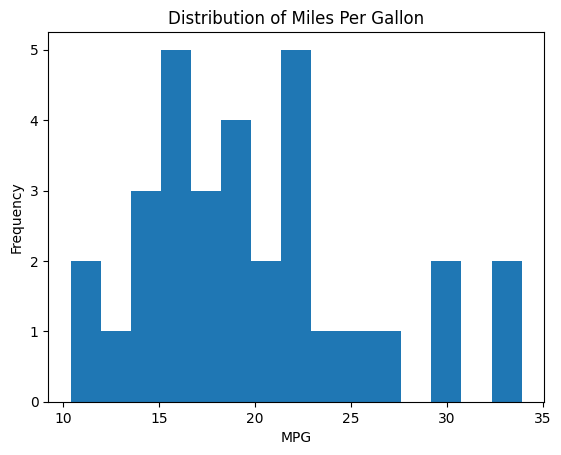

In [ ]:
#------------------------------------------------------------------------------------------------------------------------
# STEP 5: Visualize Distributions and Relationships
#------------------------------------------------------------------------------------------------------------------------

# Our target variable to predict will be "mpg"
# Indentify the distribution of the target variable
plt.figure()
plt.hist(df['mpg'], bins=15) # Make sure to adjust bin size
plt.title("Distribution of Miles Per Gallon")
plt.xlabel("MPG")
plt.ylabel("Frequency")
plt.show()

In [ ]:
df.columns

Index(['mpg', 'cyl', 'disp', 'hp', 'drat', 'wt', 'qsec', 'vs', 'am', 'gear',
       'carb'],
      dtype='object')

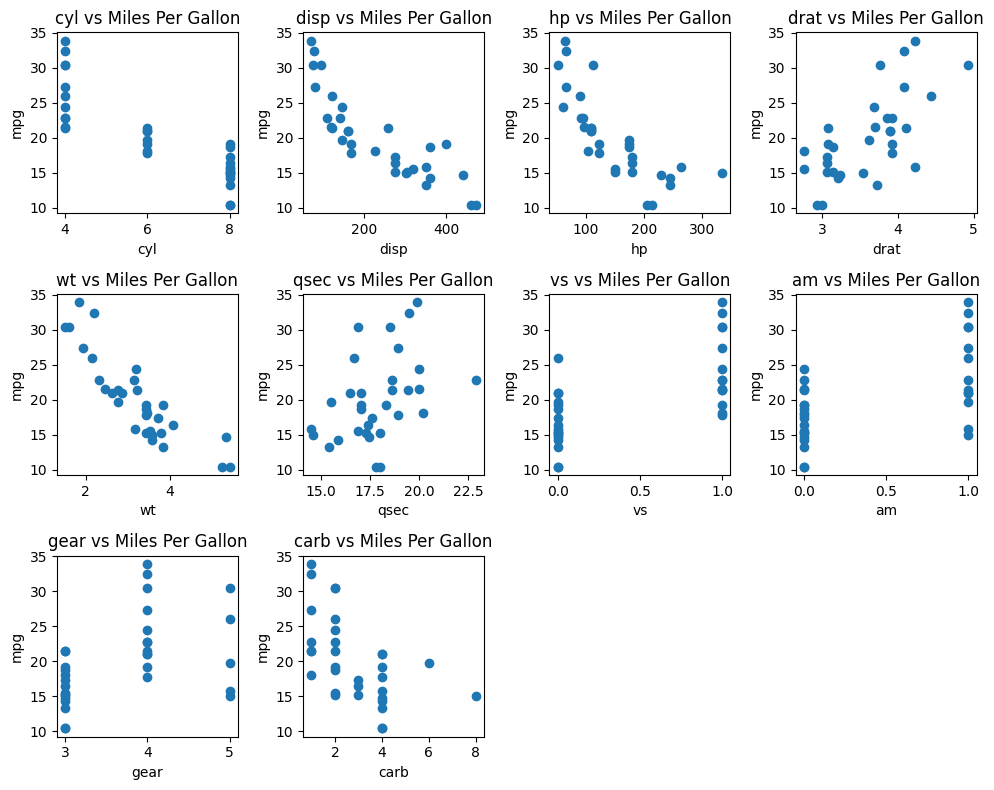

In [ ]:
# Visualize the relationships between features and the target variable
features = ['cyl', 'disp', 'hp', 'drat', 'wt', 'qsec', 'vs', 'am', 'gear',
       'carb']

plt.figure(figsize=(10,8))

for i, col in enumerate(features, 1):
    plt.subplot(3, 4, i) # Make sure to adjust subplot perameters to account for more columns
    plt.scatter(df[col], df['mpg'])
    plt.xlabel(col)
    plt.ylabel("mpg")
    plt.title(f"{col} vs Miles Per Gallon")

plt.tight_layout()
plt.show()

Question: Why might we not exclude outliers with this dataset?

Response: We may choose not to exclude outliers because the dataset is very small, so removing observations could significantly reduce the amount of data available for training the model. Additionally, some outliers may represent real-world variation rather than errors, and removing them could cause the model to miss important patterns.

## Simple Linear Regression

Create a simple linear regression model with our target variable "mpg" and a variable of your choosing.

Hint: Use the scatterplots created above to determine which feature may be a good candidate.


In [ ]:
# Isolate target and feature variables
X = df[['wt']]
y = df['mpg']

Question: Which feature did you choose and why?

Response: After creating scatter plots of each numeric variable against mpg, I chose wt because it showed a strong linear relationship. As weight increases, mpg tends to decrease in a consistent pattern, making it a strong predictor for the model.

In [ ]:
# Train Test Split 80/20

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# Create model/fit
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

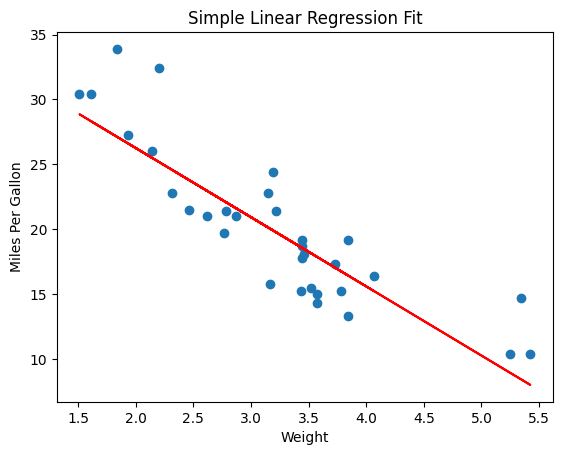

In [ ]:
# Visualize the model

plt.scatter(df['wt'], df['mpg'])
plt.plot(df['wt'], model.predict(df[['wt']]), color='red')
plt.xlabel("Weight")
plt.ylabel("Miles Per Gallon")
plt.title("Simple Linear Regression Fit")
plt.show()

In [ ]:
# Display the simple linear regression equation
intercept = model.intercept_
slope = model.coef_[0]

print(f"mpg = {intercept:.2f} + ({slope:.2f} * wt)")

mpg = 36.94 + (-5.34 * wt)


In [ ]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# Simple model
y_pred = model.predict(X_test)

r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)

print(f"R²: {r2:.3f}")
print(f"MSE: {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"MAE: {mae:.2f}")

R²: 0.688
MSE: 12.48
RMSE: 3.53
MAE: 3.00



Question: Interpret these regression metrics in your own words.

Response:  The R² value of 0.688 means that about 68.8% of the variation in mpg is explained by the model, indicating a moderately strong fit. The MSE of 12.48 shows the average squared prediction error, with larger errors having a greater impact. The RMSE of 3.53 suggests that, on average, the model’s predictions are about 3.53 mpg off from the actual values. The MAE of 3.00 indicates that the average absolute error is about 3 mpg, meaning predictions are typically within 3 mpg of the true value.

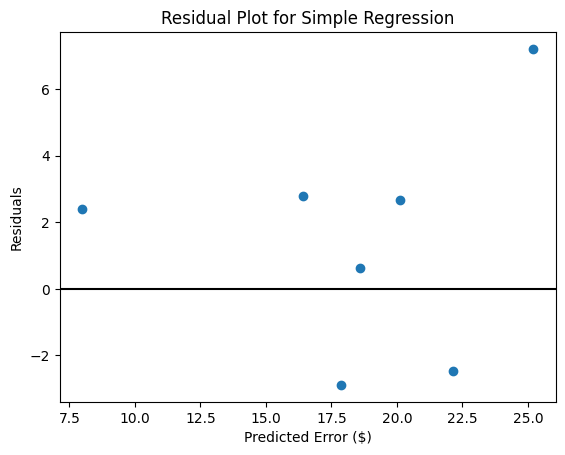

In [ ]:
# Check Other Assumptions

residuals = y_test - y_pred

plt.scatter(y_pred, residuals)
plt.axhline(0, color = 'black')
plt.xlabel("Predicted Error ($)")
plt.ylabel("Residuals")
plt.title("Residual Plot for Simple Regression")
plt.show()

Question: Does the plot above show our model meets the assumption of homoscadasticity?

Response: The plot does not show clear evidence of heteroscedasticity. The residuals appear to be randomly scattered around the horizontal axis without a consistent pattern. However, because the sample size is very small due to the 80/20 split on a dataset with only 32 observations, it is difficult to make a definitive conclusion about constant variance.

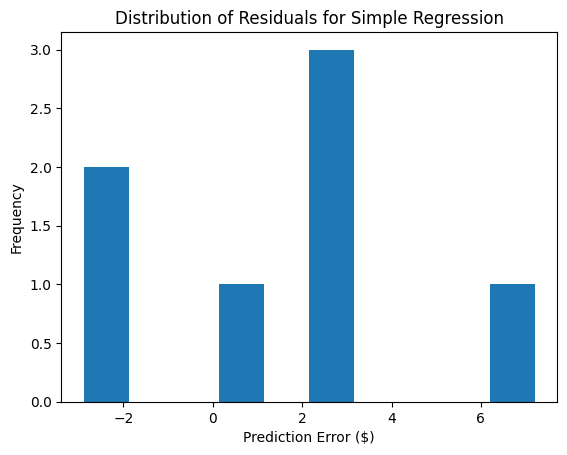

In [ ]:
# Plot the distribution of residuals
plt.figure()
plt.hist(residuals, bins=10)
plt.title("Distribution of Residuals for Simple Regression")
plt.xlabel("Prediction Error")
plt.ylabel("Frequency")
plt.show()

Question: Is the distribution of residuals skewed or symmetric? If skewed in what direction?

Response:
The distribution of residuals appears fairly symmetric overall, though it is difficult to assess definitively due to the small sample size. There may be a slight right skew, but with so few observations, the distribution can reasonably be considered approximately normal.

## Multiple Regression
Next, we add additional features to see whether model performance improves.

In [ ]:
df.columns

Index(['mpg', 'cyl', 'disp', 'hp', 'drat', 'wt', 'qsec', 'vs', 'am', 'gear',
       'carb'],
      dtype='object')

In [ ]:
# Use features that showed meaningful relationships with price and are available as numeric variables
X_m = df[['cyl', 'disp', 'hp', 'drat', 'wt', 'qsec', 'vs', 'am', 'gear',
       'carb']]
y_m = df['mpg']

Question: Which features did you add and why?

Response: I included the remaining numeric features (cyl, disp, hp, drat, qsec, vs, am, gear, and carb) in the multiple regression model to incorporate additional factors that may influence mpg. While wt showed the strongest individual relationship, combining multiple features allows the model to account for different aspects of a car’s design and performance, which can improve overall predictive power.

In [ ]:
# Train Test Split 80/20

from sklearn.model_selection import train_test_split

X_m_train, X_m_test, y_m_train, y_m_test = train_test_split(X_m, y_m, test_size=0.2, random_state=42)

In [ ]:
# Create model/fit
from sklearn.linear_model import LinearRegression

model_m = LinearRegression()
model_m.fit(X_m_train, y_m_train)

LinearRegression()

In [ ]:
# Display the multiple regression equation
# Note: Larger coefficients does not indicate variable importance. Coefficient size is affected by variable scale.
intercept = model_m.intercept_
coefficients = model_m.coef_
features = X_m.columns

equation = f"mpg = {intercept:.2f}"

for feature, coef in zip(features, coefficients):
    equation += f" + ({coef:.2f} * {feature})"

print(equation)

mpg = -5.59 + (-0.48 * cyl) + (0.02 * disp) + (-0.01 * hp) + (1.00 * drat) + (-4.86 * wt) + (1.84 * qsec) + (-1.94 * vs) + (1.08 * am) + (1.33 * gear) + (0.15 * carb)


In [ ]:
# Multi model metrics
y_m_pred = model_m.predict(X_m_test)

r2_m = r2_score(y_m_test, y_m_pred)
mse_m = mean_squared_error(y_m_test, y_m_pred)
rmse_m = np.sqrt(mse_m)
mae_m = mean_absolute_error(y_m_test, y_m_pred)

print(f"R²: {r2_m:.3f}")
print(f"MSE: {mse_m:.2f}")
print(f"RMSE: {rmse_m:.2f}")
print(f"MAE: {mae_m:.2f}")

R²: 0.747
MSE: 10.13
RMSE: 3.18
MAE: 2.24



Question: Interpret these regression metrics in your own words.

Response: The R² value of 0.747 indicates that the model explains about 74.7% of the variation in mpg, showing an improvement over the simple regression model. The MSE of 10.13 and RMSE of 3.18 suggest that prediction errors are moderate, with RMSE indicating an average error of just over 3 mpg. The MAE of 2.24 shows that typical prediction errors are slightly lower, meaning most predictions are fairly close to the actual values. Overall, these metrics suggest the multiple regression model provides more accurate predictions than the simpler model.

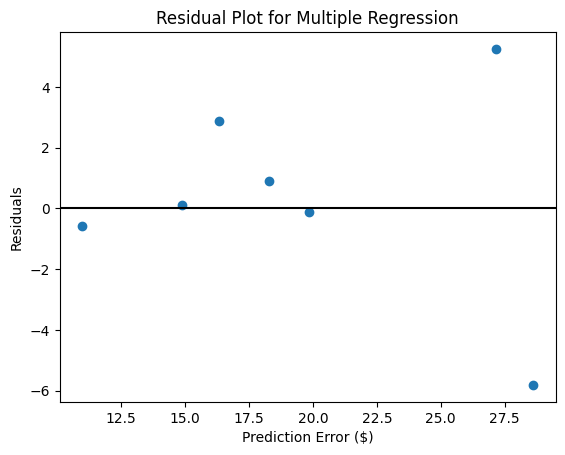

In [ ]:
# Predict on test data
residuals_m = y_m_test - y_m_pred

plt.figure()
plt.scatter(y_m_pred, residuals_m)
plt.axhline(0, color='black')
plt.xlabel("Prediction Error ($)")
plt.ylabel("Residuals")
plt.title("Residual Plot for Multiple Regression")
plt.show()


Question: Does the plot above show our model meets the assumption of homoscadasticity?

Response: The residuals appear to be randomly scattered around zero with no clear pattern, which suggests that the assumption of homoscedasticity is reasonably met. However, due to the small sample size, this conclusion should be interpreted with caution.

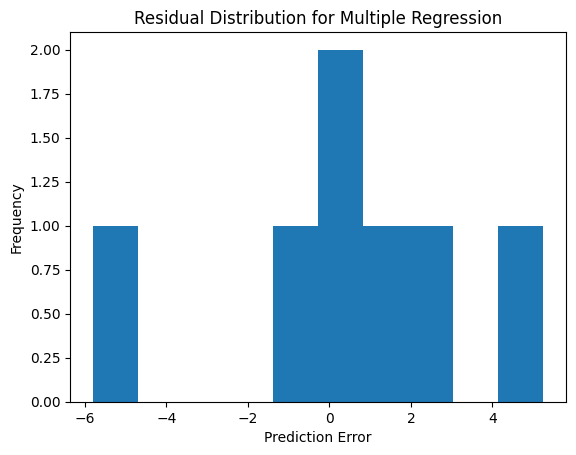

In [ ]:
plt.figure()
plt.hist(residuals_m, bins=10)
plt.title("Residual Distribution for Multiple Regression")
plt.xlabel("Prediction Error")
plt.ylabel("Frequency")
plt.show()

Question: Is the distribution of residuals skewed or symmetric? If skewed in what direction?

Response: The distribution of residuals appears roughly symmetric around zero, though it is difficult to assess definitively due to the small sample size. There may be slight skew from a few larger residuals, but overall it does not show a strong directional skew.

## Compare the Performance of Both Models

In [ ]:
# Compare both model's metrics in a table
metrics_df = pd.DataFrame({
    "Metric": ["R²", "MSE", "RMSE", "MAE"],
    "Simple Model": [r2, mse, rmse, mae],
    "Multiple Model": [r2_m, mse_m, rmse_m, mae_m]
}).set_index("Metric")

metrics_df = metrics_df.map(lambda x: f"{x:.2f}")

# This applies a small function to every value in the table.
# The function takes a value x and formats it to two decimal places.

print(metrics_df)

       Simple Model Multiple Model
Metric                            
R²             0.69           0.75
MSE           12.48          10.13
RMSE           3.53           3.18
MAE            3.00           2.24




Question: Which model performs the best. Use the metrics to justify your response.

Response: The multiple linear regression model performs better because it has a higher R² (0.75 vs. 0.69), indicating it explains more of the variation in mpg. It also has lower MSE, RMSE, and MAE, meaning its predictions are more accurate and have smaller errors on average. Overall, this suggests the multiple model provides more reliable predictions than the simple model.

## Applying the Model to New Data
Using your best-performing model, predict the mpg of a 1975 Ford Granada with the following specifications: cyl:6, disp: 250, hp: 72, wt: 3.4, drat: 2.79, qsec: 22.4, vs: 1, am: 0, gear: 3, carb: 1

source: https://www.automobile-catalog.com/performance/1975/852245/ford_granada_2-door_sedan_250_six.html

In [ ]:
# Create single row dataframe
new_car = pd.DataFrame({
    'cyl': [6],
    'disp': [250],
    'hp': [72],
    'drat': [2.79],
    'wt': [3.4],
    'qsec': [22.4],
    'vs': [1],
    'am': [0],
    'gear': [3],
    'carb': [1]
})
# Predict using best performing model
new_pred = model_m.predict(new_car)[0]

print(f"Predicted mpg: {new_pred:,.2f}")

Predicted mpg: 25.14


Question: Given that the advertised mpg for a 1975 Ford Granada was about 18.8 mpg, how do you think your model performed?

Response: My model predicted 25.14 mpg, which is notably higher than the advertised value of 18.8 mpg, indicating an overestimation. This suggests that while the model performs well on the dataset overall, it may not generalize perfectly to new observations. Differences between the input features and the training data or approximation of values could contribute to this discrepancy.

